In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

In [2]:
path = r'E:\E-commerce Analysis\Data\processed\fato_itens_tratada.csv'

In [5]:
df = pd.read_csv(path, encoding='utf-8')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 8 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   order_id                  112650 non-null  str    
 1   order_purchase_timestamp  112650 non-null  str    
 2   product_id                112650 non-null  str    
 3   product_category_name     112650 non-null  str    
 4   seller_id                 112650 non-null  str    
 5   price                     112650 non-null  float64
 6   freight_value             112650 non-null  float64
 7   total_payment             112650 non-null  float64
dtypes: float64(3), str(5)
memory usage: 6.9 MB


In [9]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['product_category_name'] = df['product_category_name'].astype('category')
df.info()   

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 8 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   order_id                  112650 non-null  str           
 1   order_purchase_timestamp  112650 non-null  datetime64[us]
 2   product_id                112650 non-null  str           
 3   product_category_name     112650 non-null  category      
 4   seller_id                 112650 non-null  str           
 5   price                     112650 non-null  float64       
 6   freight_value             112650 non-null  float64       
 7   total_payment             112650 non-null  float64       
dtypes: category(1), datetime64[us](1), float64(3), str(3)
memory usage: 6.1 MB


In [17]:
df.head()

,order_id,order_purchase_timestamp,product_id,product_category_name,seller_id,price,freight_value,total_payment
0,008fab5602c441d51f30b1464f5d4643,2017-02-22 10:37:41,f23c48d81cd6a0c87f5c3b14aac68371,beleza_saude,ebd2d60905fb58271facef5596b620d3,49.99,15.56,65.55
1,016fbc333d66b414be541c6159576c40,2018-05-30 18:09:10,b0cd550945da1de6eb9cb69595d540df,esporte_lazer,6b243f80ed07b10f0e8aa0f21a205f3c,84.90,18.52,103.42
2,01835ef41c5ac66dd9ec6084fa1d0533,2017-05-11 21:36:10,bbaef2eadf31fe3ea6702077398be06c,perfumaria,cc419e0650a3c5ba77189a1882b7556a,56.99,15.15,72.14
3,01a75ac3dd000b7628a684be97c29234,2018-01-23 10:32:39,b5c114b11d53b6fd85a6a90790f0b479,utilidades_domesticas,0adac9fbd9a2b63cccaac4f8756c1ca8,42.90,15.10,58.00
4,03720fdc92032ee4abd471d172006ab0,2018-08-05 21:34:54,dd2ca29c9d0f93d3b1d28d7d7ee3025c,moveis_sala,5b0cc932433fa5184b5b94bfe6bcc256,99.00,44.49,143.49


In [14]:
#Faturamento total por valor
total_faturamento = df['price'].sum()
print(f'Total de faturamento: R${total_faturamento:,.2f}')

Total de faturamento: R$13,591,643.70


In [16]:
#Faturamento total por frete    
total_frete = df['freight_value'].sum()
print(f'Total de frete: R${total_frete:,.2f}')

Total de frete: R$2,251,909.54


In [26]:
#Faturamento total de frete por categoria de produto
faturamento_frete_categoria = df.groupby('product_category_name')['freight_value'].sum().sort_values(ascending=False)
print(faturamento_frete_categoria)

product_category_name
cama_mesa_banho                                  204693.04
beleza_saude                                     182566.73
moveis_decoracao                                 172749.30
esporte_lazer                                    168607.51
informatica_acessorios                           147318.08
                                                   ...    
portateis_cozinha_e_preparadores_de_alimentos       309.76
cds_dvds_musicais                                   224.99
pc_gamer                                            133.57
fashion_roupa_infanto_juvenil                        95.51
seguros_e_servicos                                   41.22
Name: freight_value, Length: 74, dtype: float64


In [19]:
#Faturamento total por categoria de produto
faturamento_categoria = df.groupby('product_category_name')['price'].sum().sort_values(ascending=False)
print(faturamento_categoria)

product_category_name
beleza_saude                     1258681.34
relogios_presentes               1205005.68
cama_mesa_banho                  1036988.68
esporte_lazer                     988048.97
informatica_acessorios            911954.32
                                    ...    
flores                              1110.04
casa_conforto_2                      760.27
cds_dvds_musicais                    730.00
fashion_roupa_infanto_juvenil        569.85
seguros_e_servicos                   283.29
Name: price, Length: 74, dtype: float64


In [20]:
#Ticket médio por categoria de produto
ticket_medio_categoria = df.groupby('product_category_name')['price'].mean().sort_values(ascending=False)
print(ticket_medio_categoria)

product_category_name
pcs                            1098.340542
portateis_casa_forno_e_cafe     624.285658
eletrodomesticos_2              476.124958
agro_industria_e_comercio       342.124858
instrumentos_musicais           281.616000
                                  ...     
alimentos_bebidas                54.602446
cds_dvds_musicais                52.142857
fraldas_higiene                  40.194615
flores                           33.637576
casa_conforto_2                  25.342333
Name: price, Length: 74, dtype: float64


In [ ]:
#Medidas de dispersão do preço dos produtos - Alta variabilidade nos preços dos produtos, indicando uma ampla gama de preços, desde itens mais acessíveis até produtos de alto valor.
df['price'].var()
df['price'].std()
df['price'].mean()
print(f"Variância: {df['price'].var():,.2f}")
print(f"Desvio Padrão: {df['price'].std():,.2f}")
print(f"Média: {df['price'].mean():,.2f}")

Variância: 33,721.42
Desvio Padrão: 183.63
Média: 120.65


In [22]:
#Coeficiente de Variação - Alta Variabilidade 
cv = 183.63 / 120.65
print(f"Coeficiente de Variação: {cv:.2f}")

Coeficiente de Variação: 1.52


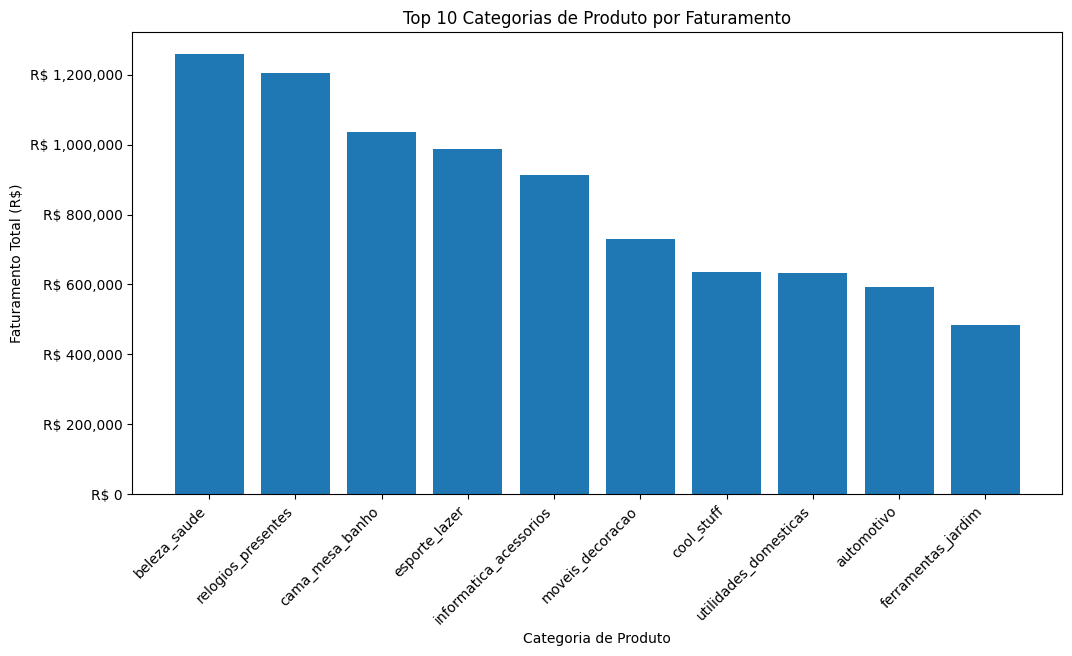

In [47]:
#Top 10 categorias de produto por faturamento
top_10_categorias = faturamento_categoria.head(10)
plt.figure(figsize=(12, 6))
plt.bar(top_10_categorias.index, top_10_categorias.values,)
plt.title('Top 10 Categorias de Produto por Faturamento')
plt.xlabel('Categoria de Produto')
plt.ylabel('Faturamento Total (R$)')
plt.xticks(rotation=45, ha='right')

ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('R$ {x:,.0f}'))
plt.show()


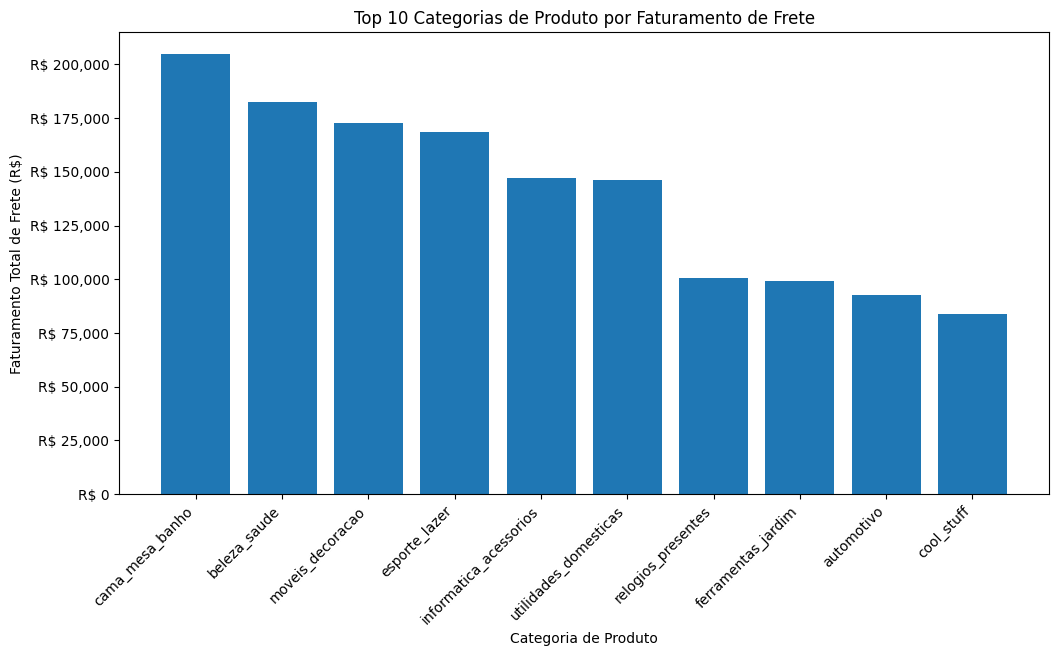

In [48]:
#Top 10 categorias com maior valor de frete
top_10_frete = faturamento_frete_categoria.head(10)
plt.figure(figsize=(12, 6))
plt.bar(top_10_frete.index, top_10_frete.values)
plt.title('Top 10 Categorias de Produto por Faturamento de Frete')
plt.xlabel('Categoria de Produto')
plt.ylabel('Faturamento Total de Frete (R$)')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('R$ {x:,.0f}'))
plt.show()
